## Delta Parameter Modeling for Surgical Optimization
This notebook trains predictive machine learning models to estimate postoperative correction for key spinopelvic alignment parameters.

The trained models are saved and later used inside the optimization pipeline to simulate surgical plan outcomes.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import PredictionErrorDisplay

from xgboost import XGBRegressor

from src import config

pd.set_option('display.max_columns', None)

## Data and Preprocessing

We load the cleaned and preprocessed dataset defined in config.DATA_PROCESSED.
This dataset contains preoperative alignment parameters, surgical plan variables, and postoperative outcomes.


In [2]:
# Load cleaned data from config path

df = pd.read_csv(config.DATA_PROCESSED)
# df.columns = df.columns.astype(str).str.replace("\n"," ").str.replace(r"\s+"," ", regex=True).str.strip()

print(f"Loaded {df.shape[0]} patients, {df.shape[1]} columns")
print(f"Data path: {config.DATA_PROCESSED}")

Loaded 271 patients, 109 columns
Data path: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/data/processed/cleaned_for_modeling.csv


## Modeling Approach

For each alignment parameter, a regression model is trained to predict the postoperative change, defined as the difference between postoperative and preoperative values. The models use patient demographics, baseline alignment measurements, and surgical plan variables as inputs. A shared preprocessing pipeline handles missing values and encodes categorical variables, with feature scaling applied where needed. Different regression algorithms are selected depending on the parameter to balance model flexibility and stability while keeping the overall framework consistent for integration into the optimization workflow.


In [3]:
df

,id,age,sex,bmi,Race,LOS_min,LOS_hours,PROC_TIME_MIN,smoking,C7CSVL_preop,SVA_preop,TK_T4_T12_preop,TK_T10_L2_preop,T4PA_preop,L1PA_preop,L1PA_ideal,T4L1PA_preop,global_tilt_preop,LL_preop,L4S1_preop,L5S1_preop,PT_preop,PI_preop,PI_LL_preop,SS_preop,cobb_prox_curve_preop,EV_prox_prox_preop,EV_distal_prox_preop,cobb_main_curve_preop,EV_prox_main_preop,EV_distal_main_preop,cobb_distal_curve_preop,EV_prox_distal_preop,EV_distal_distal_preop,FC_preop,EV_prox_FC,tscore_femneck_preop,HU_UIV_preop,HU_UIVplus1_preop,HU_UIVplus2_preop,C7CSVL_postop,SVA_postop,TK_T4_T12_postop,TK_T10_L2_postop,PJA_postop,T4PA_postop,L1PA_postop,L1PA_ideal_mismatch_postop,T4L1PA_ideal_mismatch_postop,global_tilt_postop,LL_postop,L4_S1_postop,L5_S1_postop,PT_postop,PI_postop,PI_LL_postop,SS_postop,cobb_prox_curve_postop,EV_prox_prox_postop,EV_distal_prox_postop,cobb_main_curve_postop,EV_prox_main_postop,EV_distal_main_postop,cobb_distal_curve_postop,EV_prox_distal_postop,EV_distal_distal_postop,FC_postop,num_levels,num_interbody_fusion_levels,UIV_implant,ALIF,XLIF,TLIF,num_rods,num_pelvic_screws,osteotomy,mech_fail_last,RPV_preop,RPV_score_preop,RLL_preop,RLL_score_preop,LDI_preop,LDI_score_preop,RSA_preop,RSA_score_preop,gap_age_poin_preop,gap_score_preop,gap_category,RPV_postop,RPV_score_postop,RLL_postop,RLL_score_postop,LDI_postop,LDI_score_postop,RSA_postop,RSA_score_postop,gap_age_point_postop,gap_score_postop,gap_category_postop,CCI,ASA_CLASS,ODI_preop,ODI_6wks,ODI_3mo,ODI_6mo,ODI_12mo,Prior_surgery,num_levels_cat,revision
0,347180,76,FEMALE,27.42,White,6196,103.266667,106,0.0,16.9,95.9,38.6,0.4,27.3,20.3,5.10,7.0,39.6,29.3,17.9,10.7,30.3,52.2,22.9,21.9,14.4,T5,L2,20.4,L2,L4,11.3,L4,S1,11.3,L4,-1.5,93.0,85.0,116.0,NaN,98.2,39.3,4.2,14.8,16.2,12.0,6.90,4.2,25.5,47.6,27.2,14.1,16.0,52.3,4.7,36.3,9.7,T3,L1,11.0,L1,L4,8.9,L4,S1,8.9,9,0,FS,0,0,0,3,3,0,1.0,-17.898,3,-32.064,3,61.092150,0,29.544,3,1,10.0,SD,-3.557,0,-13.826,0,57.142857,0,15.396,1,1,2.0,P,4.0,2,NaN,NaN,NaN,NaN,NaN,0,lower,0
1,348636,65,FEMALE,18.94,White,3338,55.633333,115,0.0,-6.1,40.7,41.8,-7.5,7.4,9.1,1.90,-1.7,17.1,51.8,32.5,9.3,14.1,45.8,-6.0,31.7,40.0,T2,T7,60.2,T7,T12,43.5,T12,L5,10.6,L5,-0.5,229.0,245.0,248.0,-22.3,39.3,37.3,-5.5,11.2,8.8,12.9,11.00,-4.1,17.0,52.0,33.4,17.3,16.2,55.0,3.0,38.8,30.8,T1,T7,48.1,T7,T12,30.4,T12,L5,1.7,15,3,Hook,1,0,0,2,1,0,0.0,-4.322,0,-5.596,0,62.741313,0,10.116,1,1,2.0,P,-2.650,0,-11.100,0,64.230769,0,5.600,0,1,1.0,P,2.0,3,NaN,NaN,NaN,NaN,NaN,0,higher,0
2,391848,82,FEMALE,28.12,White,29906,498.433333,195,1.0,-18.0,136.5,38.8,26.6,23.6,5.8,-2.25,17.8,38.1,13.0,23.5,18.2,22.0,37.5,24.5,15.5,7.1,T7,T12,16.2,T12,L5,NaN,NaN,NaN,12.0,L3,NaN,138.0,137.0,136.0,-15.7,51.0,50.6,5.0,8.0,10.0,3.2,5.45,6.8,20.9,32.3,21.2,12.1,14.9,33.7,NaN,NaN,8.9,T8,L2,16.8,L2,L4,4.2,L4,S1,4.2,9,1,PS,0,1,0,3,3,0,0.0,-15.625,3,-39.250,3,180.769231,3,35.100,3,1,13.0,SD,-28.883,3,-17.594,2,65.634675,0,19.724,3,1,9.0,SD,4.0,3,0,0,0,NR,NR,1,lower,1
3,437448,69,FEMALE,21.33,White,13488,224.800000,132,1.0,-44.2,80.4,19.4,20.0,16.0,3.9,-2.05,12.1,25.3,14.4,38.1,13.2,12.4,37.9,23.5,25.5,31.0,T8,L1,47.5,L1,L4,NaN,NaN,NaN,15.4,L4,-1.2,184.0,180.0,213.0,-18.6,-43.4,41.8,15.1,7.2,5.4,-4.0,-1.95,9.4,7.0,45.6,38.5,25.7,5.4,33.8,-11.8,28.4,15.5,T8,L1,24.7,L1,L4,NaN,NaN,NaN,7.5,15,2,Hook,1,0,0,3,3,0,1.0,-5.861,0,-38.098,3,264.583333,3,22.108,3,1,10.0,SD,-0.542,0,-4.356,0,84.429825,3,5.776,0,1,4.0,MD,5.0,2,NaN,NaN,NaN,NaN,NaN,0,higher,0
4,501563,72,FEMALE,24.74,Multiple,18691,311.516667,246,1.0,-28.1,72.8,35.6,4.8,21.7,22.0,6.95,-0.3,35.6,55.0,23.2,16.1,22.8,55.9,0.9,33.1,15.9,T3,T9,27.9,T9,L3,24.6,L3,S1,24.6,L3,NaN,180.0,188.0,NaN,-11.8,-16.5,36.5,11.6,2.2,13.7,14.1,7.15,-0.4,20.7,57.4,35.4,17.1,22.0,49.5,-7.9,27.5,10.3,T3,T9,13.6,T9,L3,6.4,L3,L5,6.4,9,2,PS,1,0,0,3,2,0,1.0,-8.881,2,-8.658,0,42.181818,1,23.768,3,1,7.0,SD,-10.705,2,-2.290,0,61.672474,0,11.940,1,1,4.0,MD,3.0,2,NaN,NaN,NaN,NaN,NaN,0,lower,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

Some clinical variables (e.g., ODI scores) may be stored as strings.
We explicitly convert these to numeric types to ensure valid arithmetic operations when computing delta values.

In [4]:
# Ensure ODI columns are numeric
df["ODI_preop"] = pd.to_numeric(df["ODI_preop"], errors="coerce")
df["ODI_12mo"]  = pd.to_numeric(df["ODI_12mo"], errors="coerce")

For each alignment parameter, the postoperative correction is computed as the difference between the postoperative and preoperative values. These delta variables serve as the regression targets for the modeling process. If a delta column is not already present in the dataset, it is created to ensure consistency across runs.

In [5]:
# Ensure delta columns exist
if "delta_SVA" not in df.columns:
    df["delta_SVA"] = df["SVA_postop"] - df["SVA_preop"]

if "delta_SS" not in df.columns:
    df["delta_SS"] = df["SS_postop"] - df["SS_preop"]
    
# Ensure delta_GlobalTilt exists
if "delta_GlobalTilt" not in df.columns:
    df["delta_GlobalTilt"] = (
        df["global_tilt_postop"] - df["global_tilt_preop"]
    )
if "delta_LL" not in df.columns:
    df["delta_LL"] = df["LL_postop"] - df["LL_preop"]

if "delta_L1PA" not in df.columns:
    df["delta_L1PA"] = df["L1PA_postop"] - df["L1PA_preop"]

if "delta_T4PA" not in df.columns:
    df["delta_T4PA"] = df["T4PA_postop"] - df["T4PA_preop"]

if "delta_L4S1" not in df.columns:
    df["delta_L4S1"] = df["L4_S1_postop"] - df["L4S1_preop"]

if "delta_ODI" not in df.columns:
    df["delta_ODI"] = df["ODI_12mo"] - df["ODI_preop"]


Model inputs are constructed using patient fixed preoperative parameters and surgical plan variables defined in the shared configuration file. GAP-related predictors are excluded to avoid redundancy and potential leakage. The final feature list combines baseline patient characteristics with operative planning variables.

In [6]:
# Use shared config for features

PATIENT_FIXED_COLS = config.PATIENT_FIXED_COLS
PLAN_COLS = config.PLAN_COLS

FEATURES = config.DELTA_MODEL_FEATURES.copy()

# Treat binary indicators as categorical
for col in config.BINARY_INDICATOR_COLS:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Automatically split by dtype
NUMERIC_FEATURES = df[FEATURES].select_dtypes(
    exclude=["object", "string", "category"]
).columns.tolist()

CATEGORICAL_FEATURES = df[FEATURES].select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


Features are automatically separated into numeric and categorical variables based on data type. Numeric features are imputed using the median, while categorical features are imputed and one-hot encoded. For linear models such as Ridge regression, numeric features are additionally standardized. These preprocessing steps are embedded within model pipelines to ensure consistency during training and deployment.

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(smooth="auto"))
])

ridge_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(smooth="auto")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES)
    ]
)
ridge_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ("num", ridge_numeric_transformer, NUMERIC_FEATURES),
        ("cat", ridge_categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

## Model Training

A unified training function is defined to ensure consistency across all delta models. The function splits the data into training and testing sets, applies the appropriate preprocessing pipeline, fits the specified regression model, and reports performance metrics including mean absolute error (MAE) and R². Ridge models use a scaled preprocessing pipeline, while tree-based models use the standard pipeline. This structure keeps model training consistent while allowing flexibility in algorithm choice.

In [8]:
def train_model(df, target_col, model, model_name, use_ridge=False):

    from sklearn.base import clone

    data = df[FEATURES + [target_col]].dropna(subset=[target_col])

    X = data[FEATURES]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    if use_ridge:
        base_preprocessor = clone(ridge_preprocessor)
    else:
        base_preprocessor = clone(preprocessor)

    base_preprocessor.fit(X_train, y_train)

    X_train_trans = base_preprocessor.transform(X_train)
    X_test_trans  = base_preprocessor.transform(X_test)

    if hasattr(X_train_trans, "toarray"):
        X_train_trans = X_train_trans.toarray()
        X_test_trans = X_test_trans.toarray()

    model_copy = clone(model)
    model_copy.fit(X_train_trans, y_train)

    preds = model_copy.predict(X_test_trans)

    print(f"\n{model_name}")
    print("MAE:", round(mean_absolute_error(y_test, preds), 3))
    print("R² :", round(r2_score(y_test, preds), 3))
    

    pipe = Pipeline([
        ("preprocess", base_preprocessor),
        ("model", model_copy)
    ])

    return pipe, X_train, X_test, y_train, y_test, preds

## Model Evaluation

Model performance is evaluated using mean absolute error (MAE) and R². These metrics summarize prediction accuracy and the proportion of variance explained by each model on a held-out test set. The evaluation step provides an initial assessment of predictive performance before training the final full-data models for deployment.


In [9]:
# Define models
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=5,
    oob_score=True
)

ridge_model = Ridge(alpha=1)

In [10]:
sva_model, X_train_sva, X_test_sva, y_train_sva, y_test_sva, y_pred_sva = \
    train_model(df, "delta_SVA", xgb_model, "ΔSVA Model")

ss_model, X_train_ss, X_test_ss, y_train_ss, y_test_ss, y_pred_ss = \
    train_model(df, "delta_SS", xgb_model, "ΔSS Model")

gt_model, X_train_gt, X_test_gt, y_train_gt, y_test_gt, y_pred_gt = \
    train_model(df, "delta_GlobalTilt", xgb_model, "ΔGT Model")

ll_model, X_train_ll, X_test_ll, y_train_ll, y_test_ll, y_pred_ll = \
    train_model(df, "delta_LL", rf_model, "ΔLL Model")

l1pa_model, X_train_l1pa, X_test_l1pa, y_train_l1pa, y_test_l1pa, y_pred_l1pa = \
    train_model(df, "delta_L1PA", ridge_model, "ΔL1PA Model", use_ridge=True)

t4pa_model, X_train_t4pa, X_test_t4pa, y_train_t4pa, y_test_t4pa, y_pred_t4pa = \
    train_model(df, "delta_T4PA", ridge_model, "ΔT4PA Model", use_ridge=True)

l4s1_model, X_train_l4s1, X_test_l4s1, y_train_l4s1, y_test_l4s1, y_pred_l4s1 = \
    train_model(df, "delta_L4S1", ridge_model, "ΔL4S1 Model", use_ridge=True)

odi_model, X_train_odi, X_test_odi, y_train_odi, y_test_odi, y_pred_odi = \
    train_model(df, "delta_ODI", ridge_model, "ΔODI Model", use_ridge=True)


ΔSVA Model
MAE: 27.293
R² : 0.594

ΔSS Model
MAE: 7.254
R² : 0.241

ΔGT Model
MAE: 6.721
R² : 0.514

ΔLL Model
MAE: 7.763
R² : 0.513

ΔL1PA Model
MAE: 3.48
R² : 0.503

ΔT4PA Model
MAE: 5.259
R² : 0.553

ΔL4S1 Model
MAE: 7.584
R² : 0.54

ΔODI Model
MAE: 13.207
R² : 0.588


In [11]:
def build_full_model(df, target_col, model, use_ridge=False):

    data = df[FEATURES + [target_col]].dropna(subset=[target_col])
    X = data[FEATURES]
    y = data[target_col]

    if use_ridge:
        pipe = Pipeline([
            ("preprocess", clone(ridge_preprocessor)),
            ("model", model)
        ])
    else:
        pipe = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", model)
        ])

    pipe.fit(X, y)
    return pipe

In [12]:
import joblib
from src import config

def save_model(pipe, target_col, model_name):

    target_dir = config.ARTIFACTS_DIR / target_col.replace("delta_", "")
    target_dir.mkdir(parents=True, exist_ok=True)

    bundle = {
        "pipe": pipe,
        "features": FEATURES,
        "target": target_col,
        "model_name": model_name
    }

    out_path = target_dir / f"{target_col}_model.joblib"
    joblib.dump(bundle, out_path)

    print("Saved:", out_path)

In [13]:
save_model(sva_model,  "delta_SVA", "XGBRegressor")
save_model(ss_model,   "delta_SS", "XGBRegressor")
save_model(gt_model,   "delta_GlobalTilt", "XGBRegressor")

save_model(ll_model,   "delta_LL", "RandomForest")
save_model(l1pa_model, "delta_L1PA", "Ridge")
save_model(t4pa_model, "delta_T4PA", "Ridge")
save_model(l4s1_model, "delta_L4S1", "Ridge")
save_model(odi_model,  "delta_ODI", "Ridge")

Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/SVA/delta_SVA_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/SS/delta_SS_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/GlobalTilt/delta_GlobalTilt_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/LL/delta_LL_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/L1PA/delta_L1PA_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/T4PA/delta_T4PA_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/L4S1/delta_L4S1_model.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/ODI/delta_ODI_model.joblib


## Model Diagnostics

For each alignment parameter, diagnostic plots are used to evaluate prediction behavior. These visualizations include predicted vs. actual values, residual distributions, residuals vs. predicted values, and absolute error distributions. Together, they provide insight into model fit, error spread, and potential bias patterns.

In [14]:
def plot_diagnostics_3panel(y_test, y_pred, title):

    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14)

    # Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6, marker="s")
    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--",
    )
    axes[0].set_title("Actual vs Predicted")
    axes[0].set_xlabel("Postoperative")
    axes[0].set_ylabel("Predicted")

    # Residual vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.6)
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title("Residuals vs Predicted")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual")

    # Residual Histogram
    sns.histplot(residuals, bins=15, kde=True, ax=axes[2])
    axes[2].set_title("Residual Histogram")

    plt.tight_layout()
    plt.show()

In [15]:
def plot_shap_xgb(model, X_test, title):

    import shap
    import numpy as np

    preprocess = model.named_steps["preprocess"]
    final_model = model.named_steps["model"]

    X_test_trans = preprocess.transform(X_test)

    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    feature_names = preprocess.get_feature_names_out()

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test_trans)

    shap.summary_plot(
        shap_values,
        X_test_trans,
        feature_names=feature_names,
        max_display=15,
        show=False
    )
    plt.title(f"Top Feature Drivers of {model}")
    plt.show()
    

In [16]:
def plot_shap_tree(model, X_train, X_test, title):

    import shap
    import numpy as np

    preprocess = model.named_steps["preprocess"]
    final_model = model.named_steps["model"]

    X_test_trans = preprocess.transform(X_test)

    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    feature_names = preprocess.get_feature_names_out()

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test_trans)

    shap.summary_plot(
        shap_values,
        X_test_trans,
        feature_names=feature_names,
        max_display=15,
        show=False
    )

    plt.title(f"Top Feature Drivers of {model}")
    plt.show()

In [17]:
def plot_shap_linear(model, X_train, X_test, title):

    import shap
    import numpy as np

    preprocess = model.named_steps["preprocess"]
    final_model = model.named_steps["model"]

    # Transform
    X_train_trans = preprocess.transform(X_train)
    X_test_trans  = preprocess.transform(X_test)

    # Convert sparse to dense if needed
    if hasattr(X_train_trans, "toarray"):
        X_train_trans = X_train_trans.toarray()
    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    feature_names = preprocess.get_feature_names_out()

    explainer = shap.LinearExplainer(final_model, X_train_trans)
    shap_values = explainer(X_test_trans)

    print(f"\n{title} — SHAP Beeswarm")

    shap.summary_plot(
        shap_values,
        X_test_trans,
        feature_names=feature_names,
        max_display=15
    )

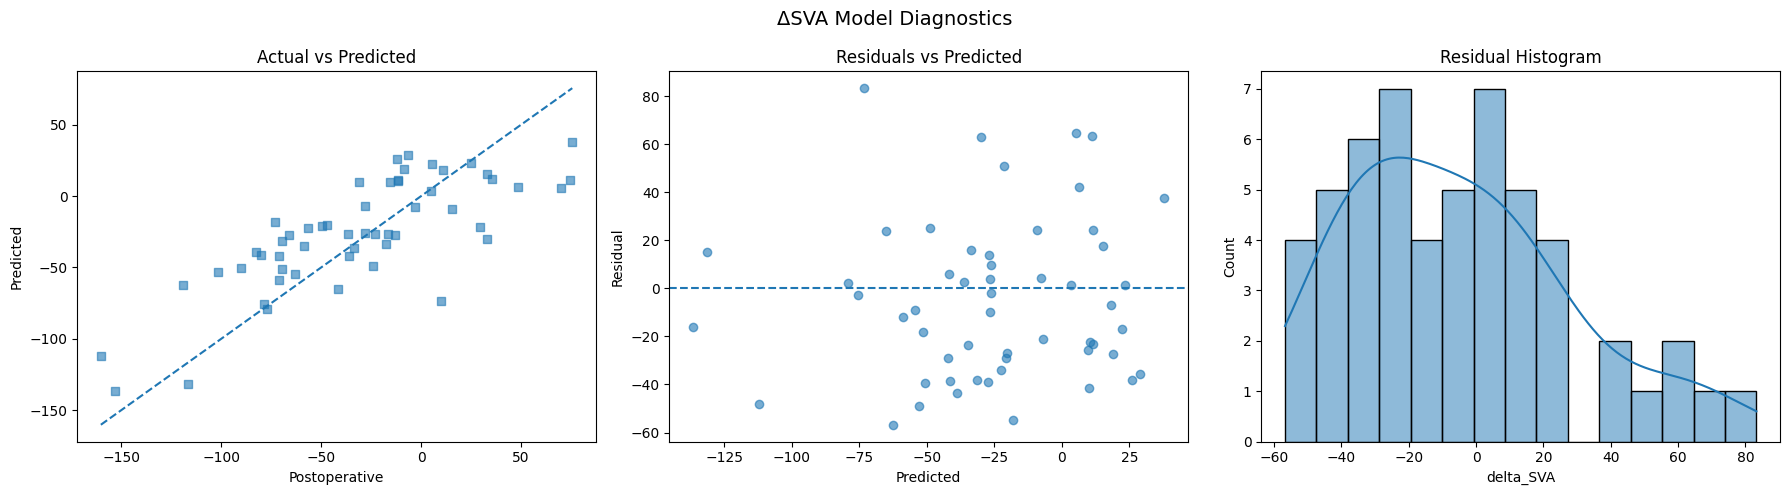

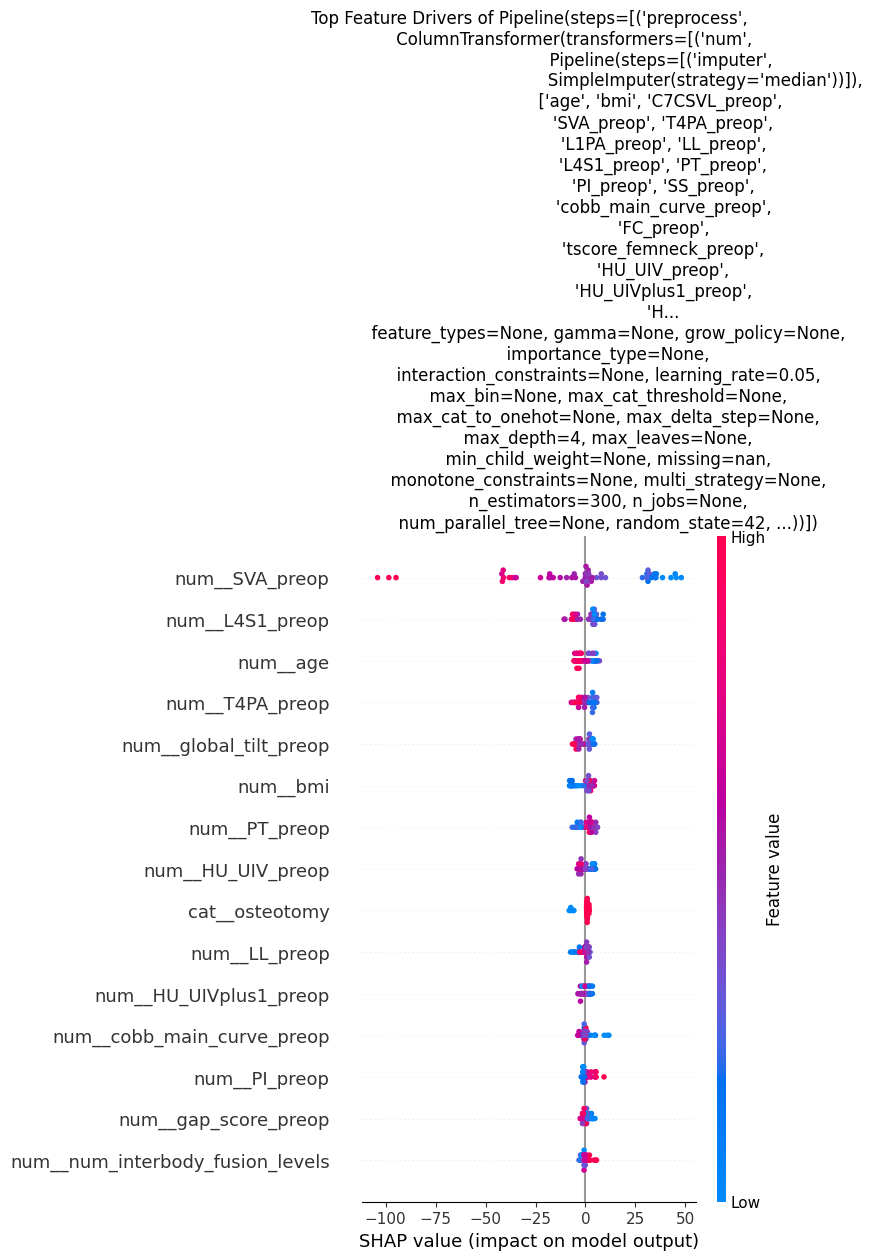

In [18]:
plot_diagnostics_3panel(
    y_test_sva,
    y_pred_sva,
    "ΔSVA Model Diagnostics"
)
plot_shap_xgb(
    sva_model,
    X_test_sva,
    "ΔSVA Model"
)

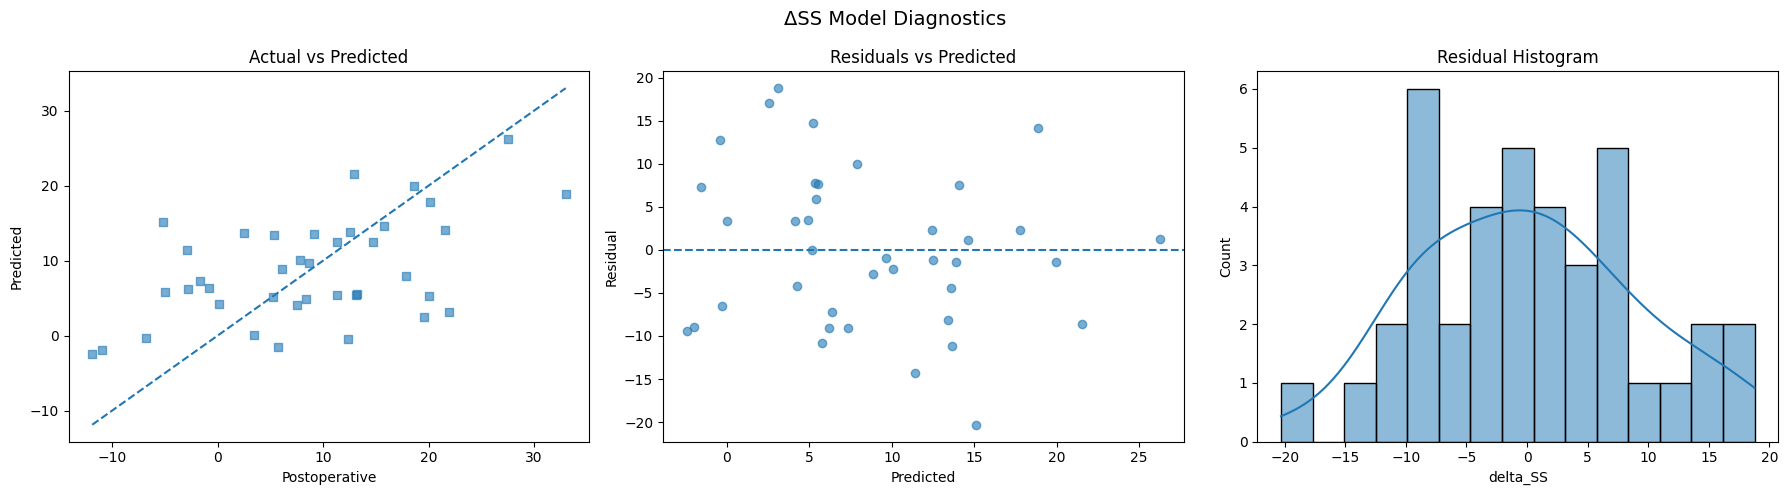

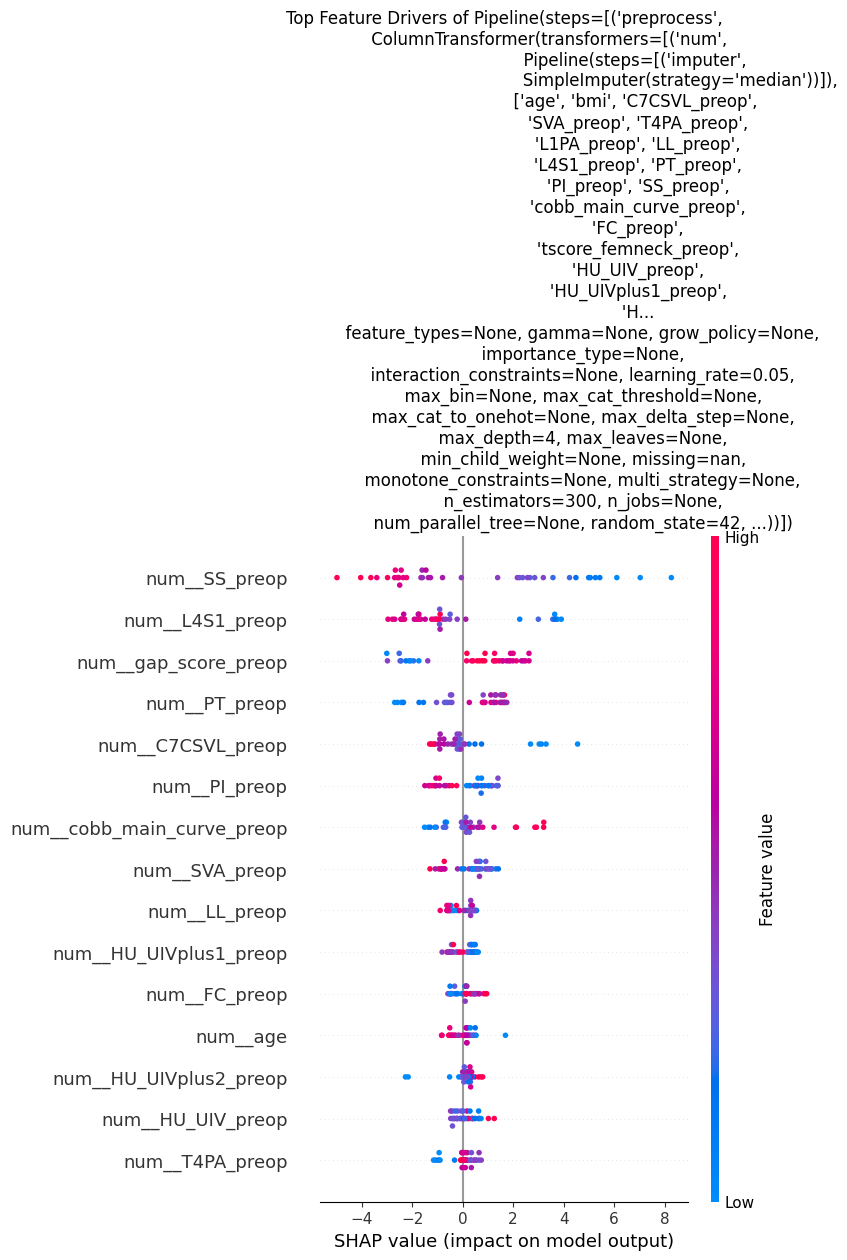

In [19]:
plot_diagnostics_3panel(
    y_test_ss,
    y_pred_ss,
    "ΔSS Model Diagnostics"
)
plot_shap_xgb(
    ss_model,
    X_test_ss,
    "ΔSS Model"
)

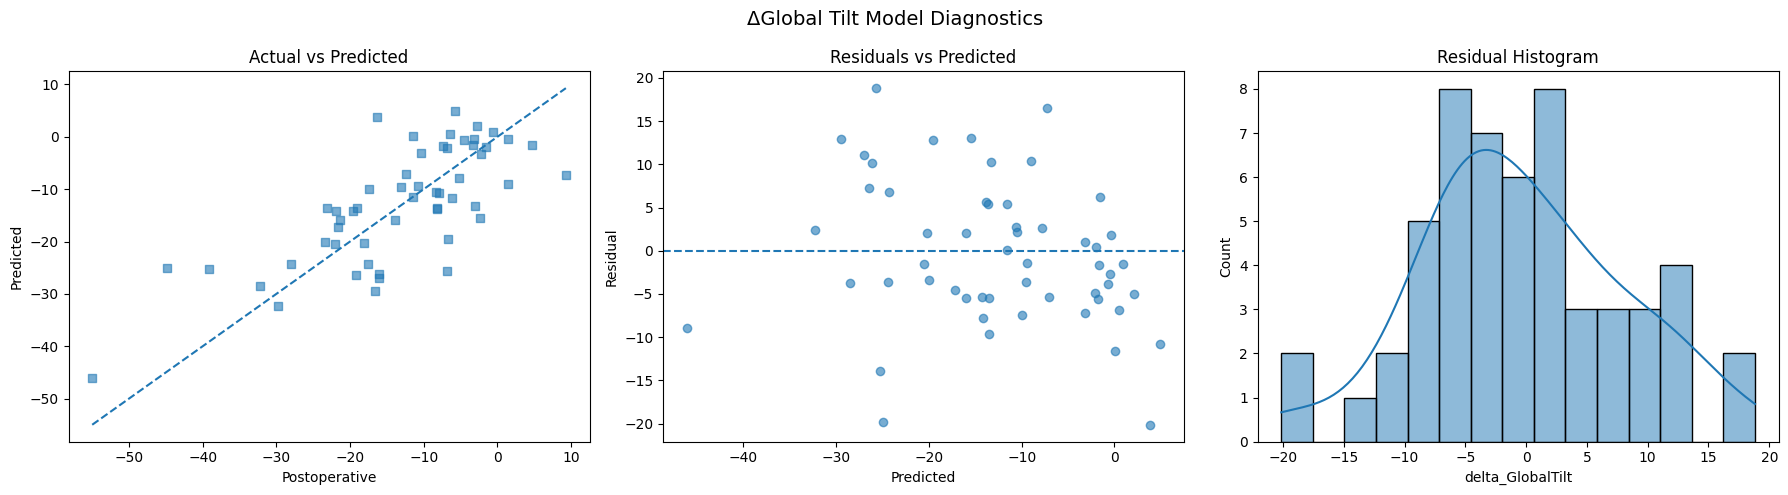

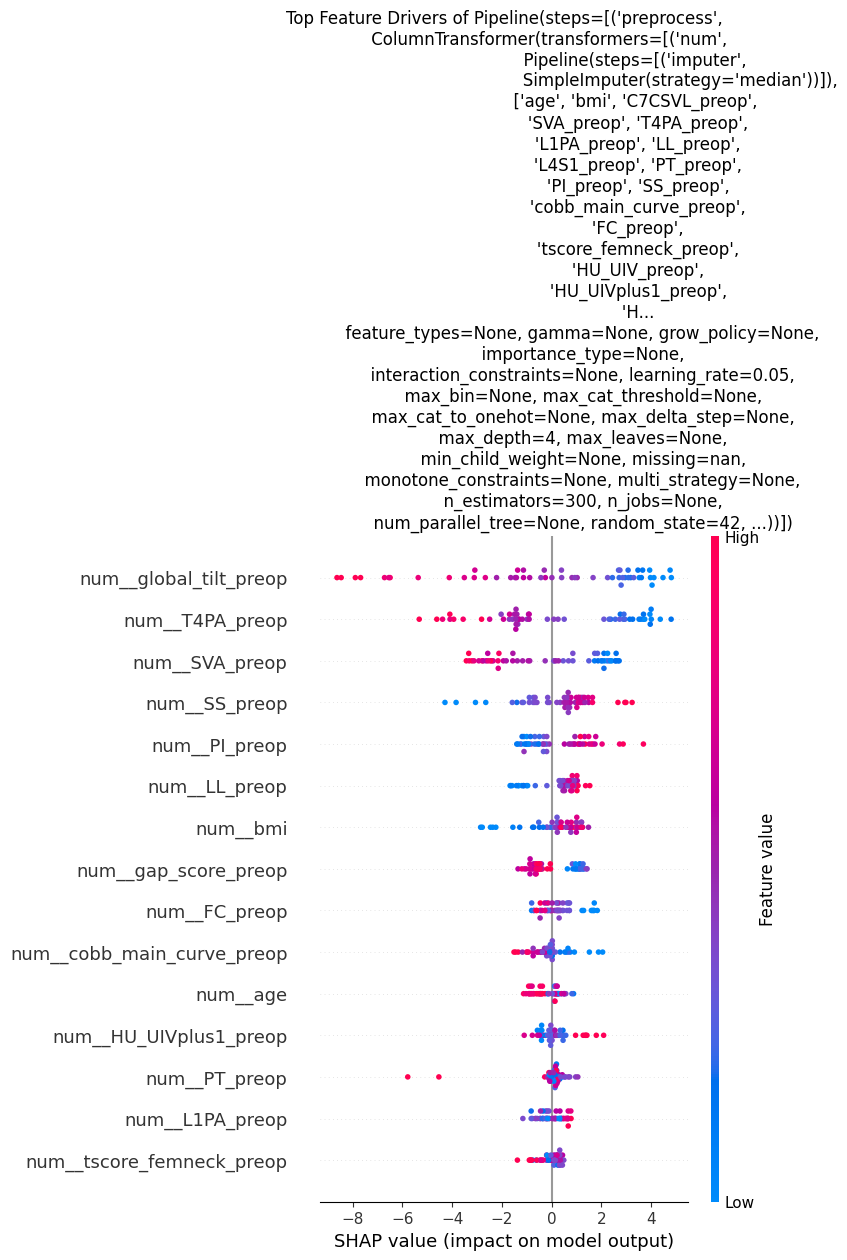

In [20]:
plot_diagnostics_3panel(
    y_test_gt,
    y_pred_gt,
    "ΔGlobal Tilt Model Diagnostics"
)
plot_shap_xgb(
    gt_model,
    X_test_gt,
    "ΔGT Model"
)

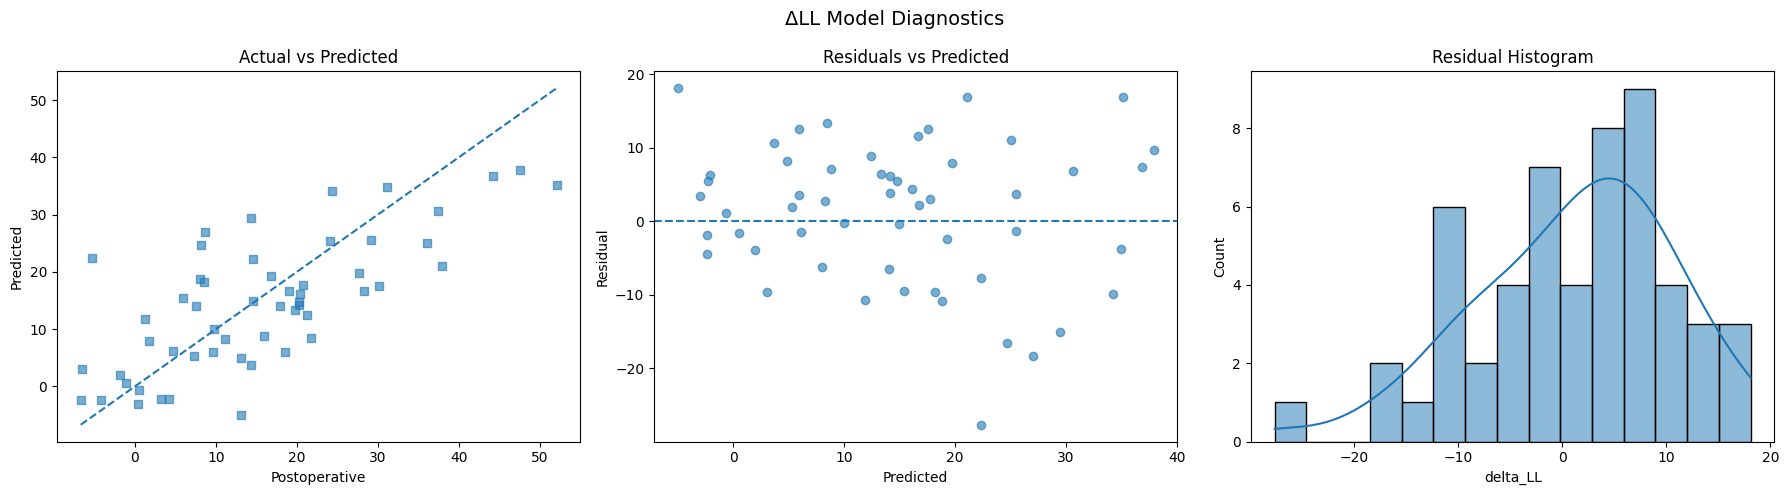

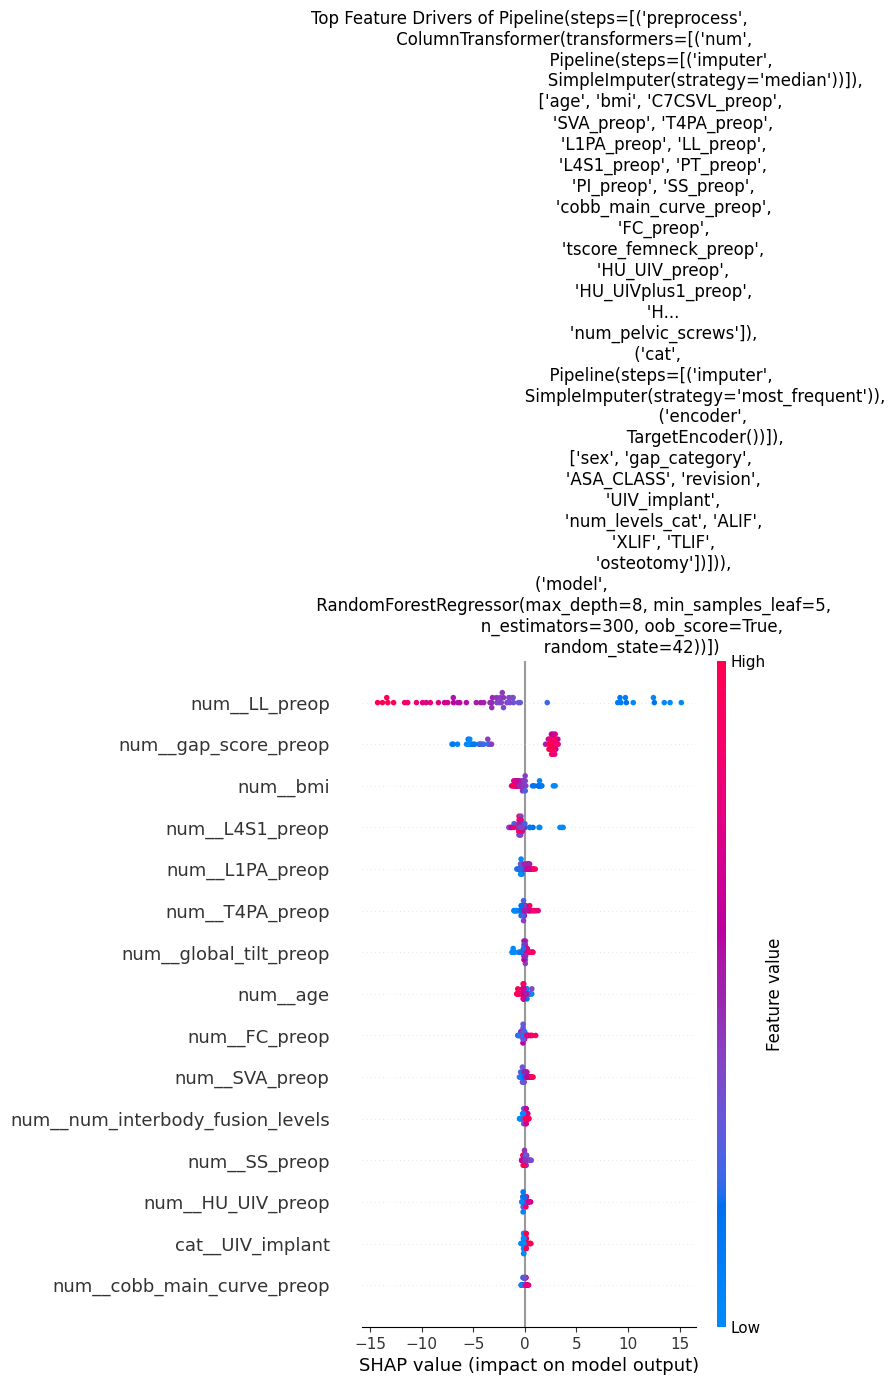

In [21]:
plot_diagnostics_3panel(
    y_test_ll,
    y_pred_ll,
    "ΔLL Model Diagnostics"
)

plot_shap_tree(
    ll_model,
    X_train_ll,
    X_test_ll,
    "ΔLL Model"
)

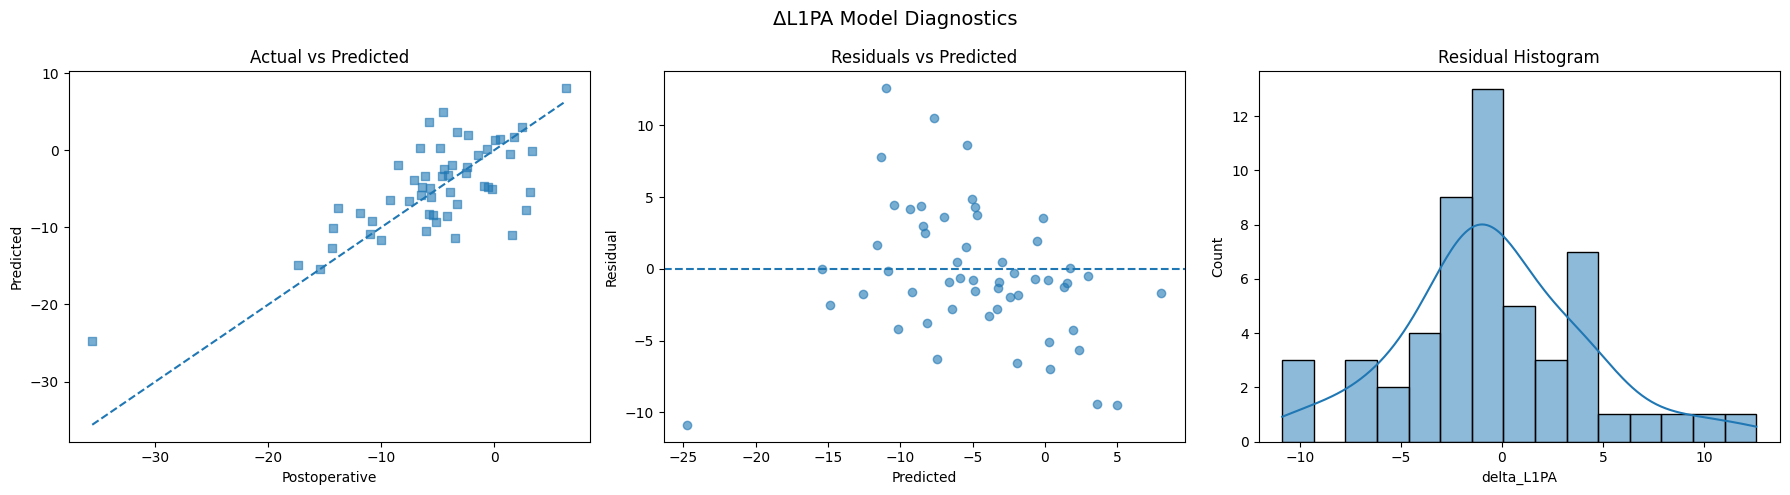


ΔL1PA Model — SHAP Beeswarm


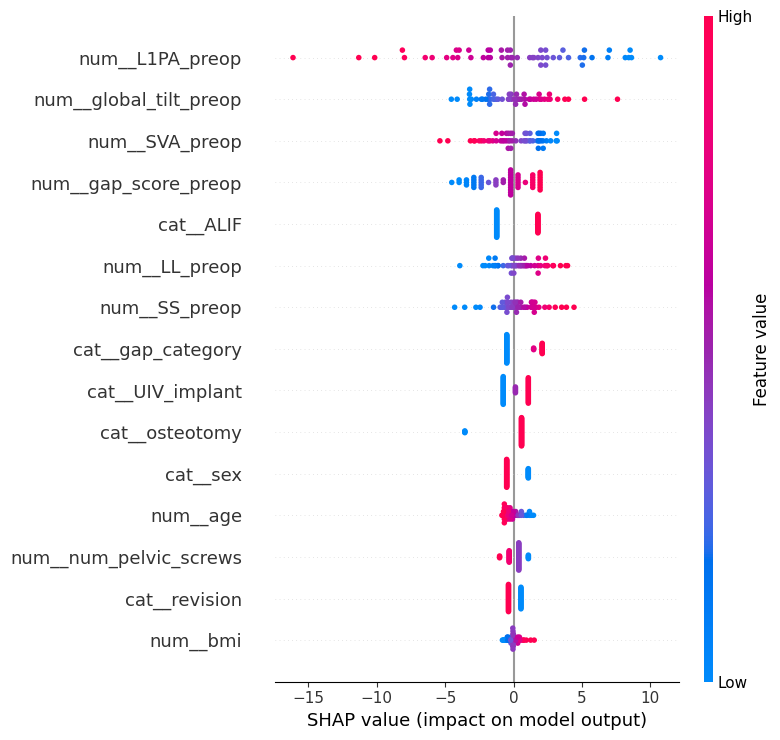

In [22]:
plot_diagnostics_3panel(
    y_test_l1pa,
    y_pred_l1pa,
    "ΔL1PA Model Diagnostics"
)

plot_shap_linear(
    l1pa_model,
    X_train_l1pa,
    X_test_l1pa,
    "ΔL1PA Model"
)

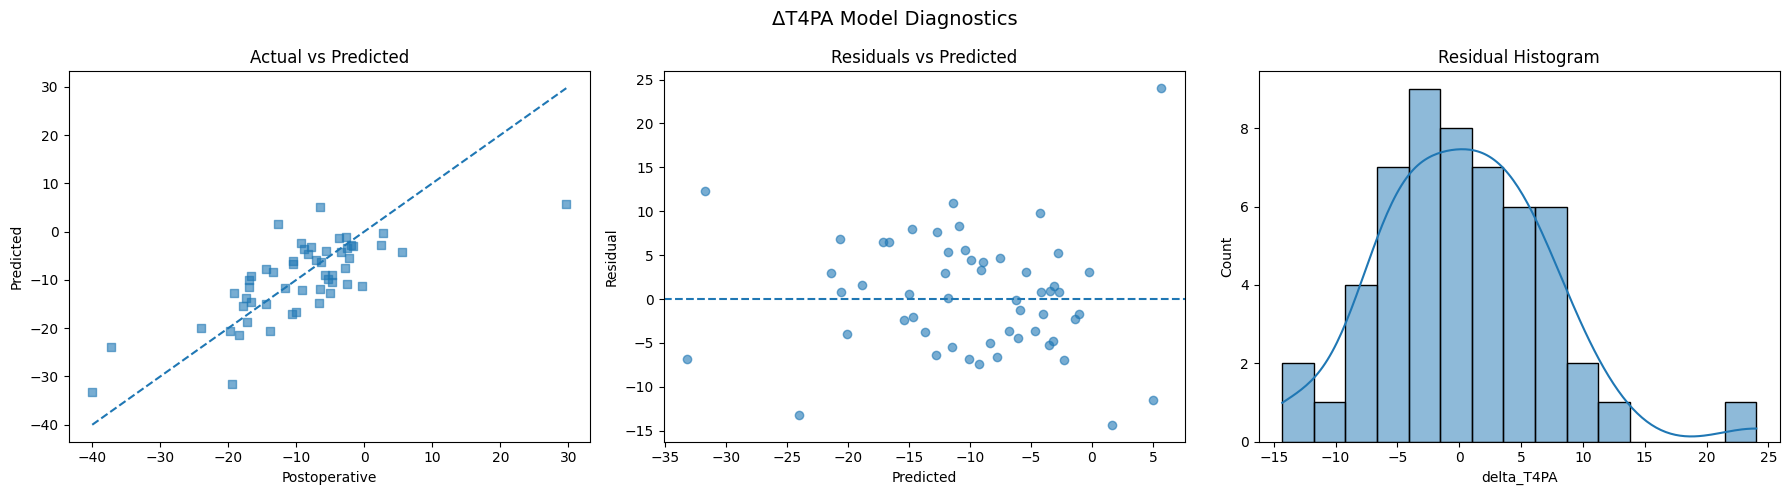


ΔT4PA Model — SHAP Beeswarm


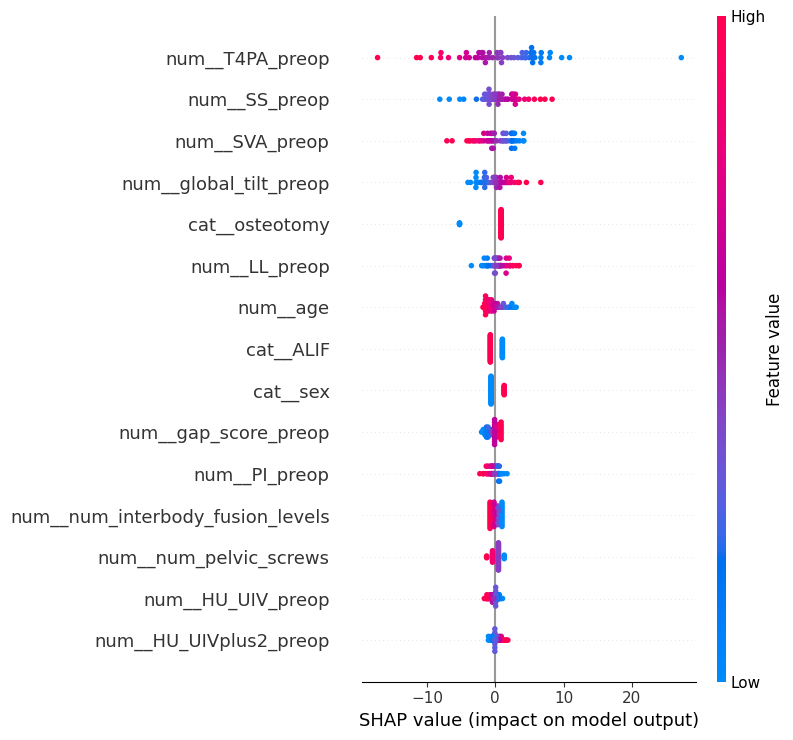

In [23]:
plot_diagnostics_3panel(
    y_test_t4pa,
    y_pred_t4pa,
    "ΔT4PA Model Diagnostics"
)

plot_shap_linear(
    t4pa_model,
    X_train_t4pa,
    X_test_t4pa,
    "ΔT4PA Model"
)

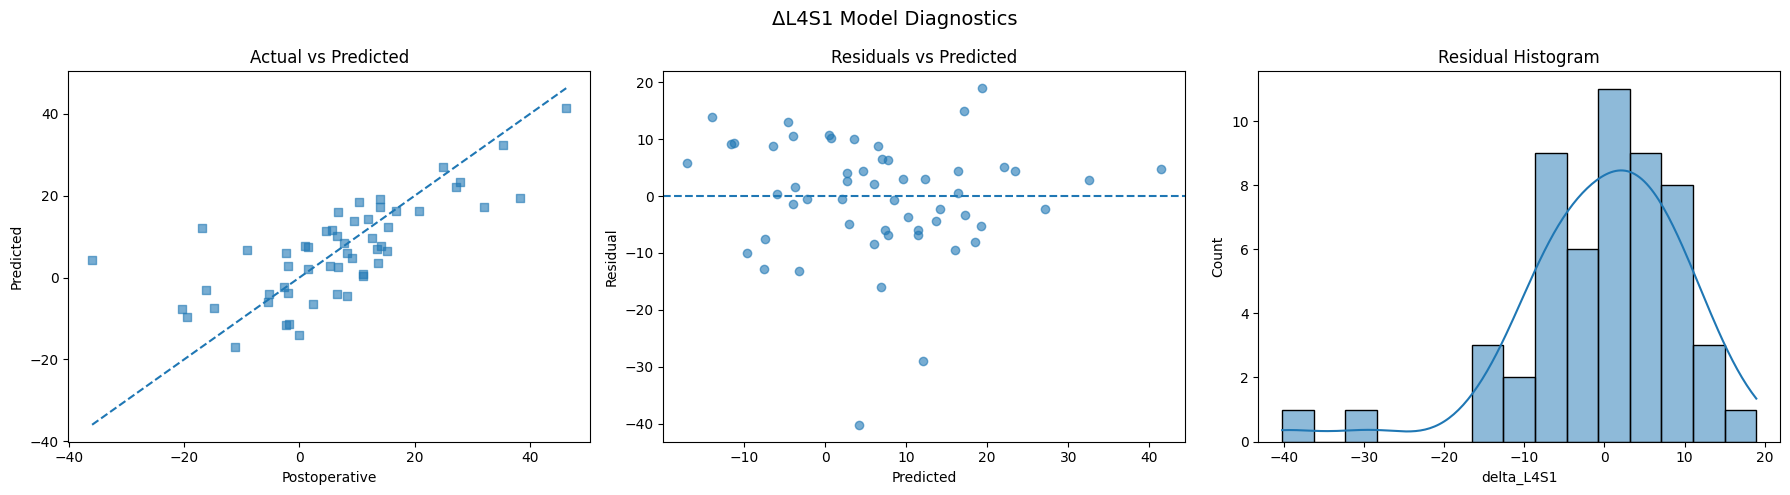


ΔL4S1 Model — SHAP Beeswarm


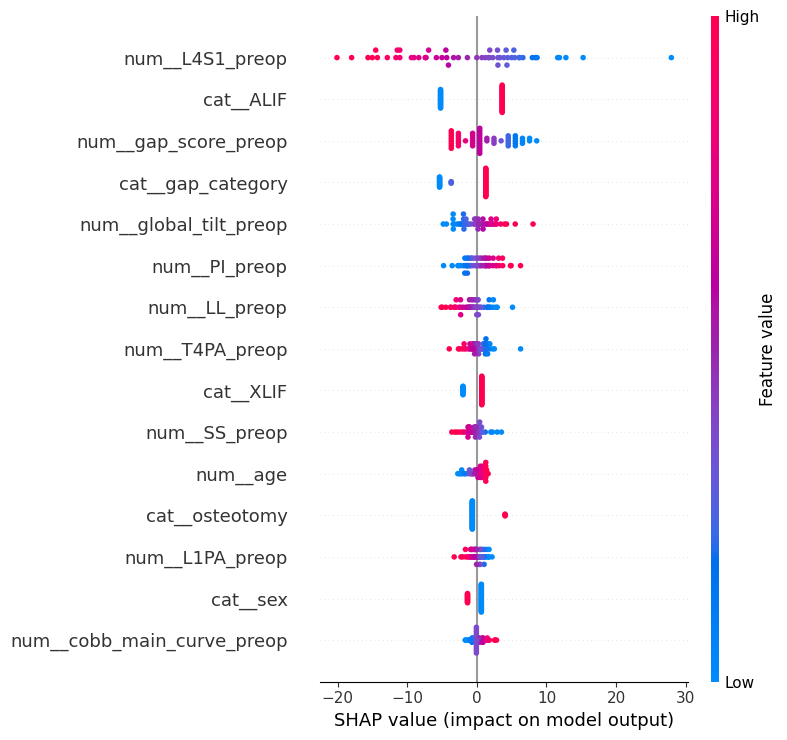

In [24]:
plot_diagnostics_3panel(
    y_test_l4s1,
    y_pred_l4s1,
    "ΔL4S1 Model Diagnostics"
)

plot_shap_linear(
    l4s1_model,
    X_train_l4s1,
    X_test_l4s1,
    "ΔL4S1 Model"
)

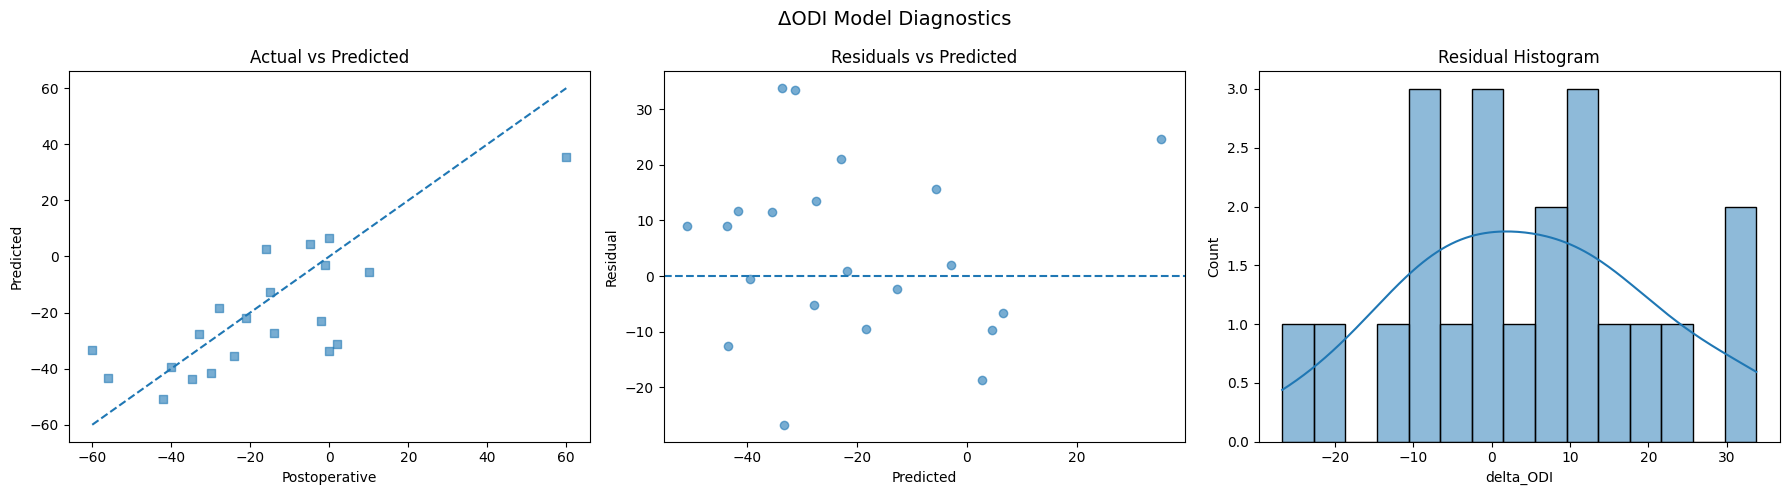


ΔODI Model — SHAP Beeswarm


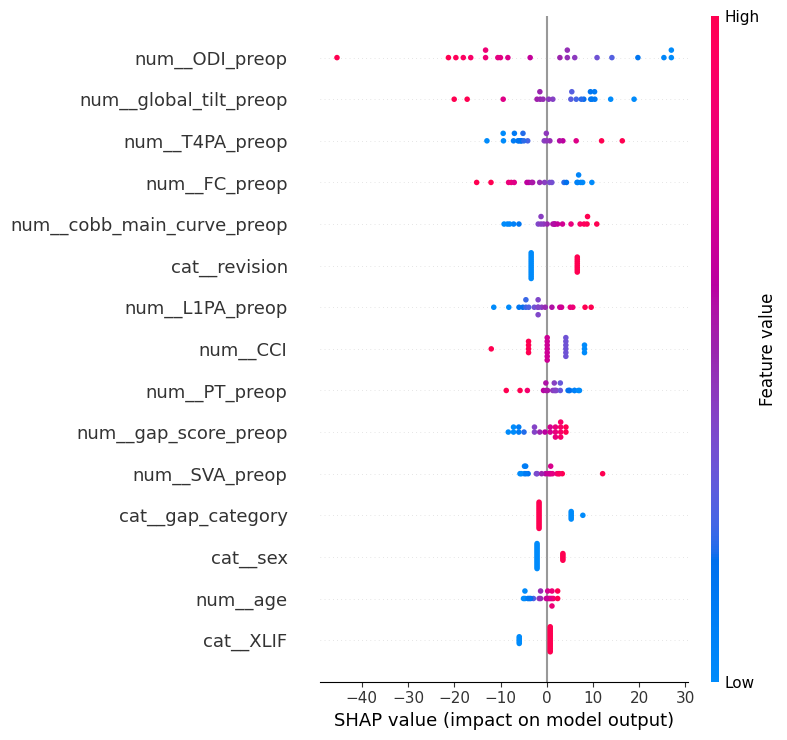

In [25]:
plot_diagnostics_3panel(
    y_test_odi,
    y_pred_odi,
    "ΔODI Model Diagnostics"
)

plot_shap_linear(
    odi_model,
    X_train_odi,
    X_test_odi,
    "ΔODI Model"
)